In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv(
    "paysim.csv.zip"
)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
#Check Dataset Shape
df.shape

(6362620, 11)

In [4]:
#Create Transaction Frequency Feature
#How many transactions does each customer perform?
df['transaction_frequency'] = (
    df.groupby('nameOrig')
      ['nameOrig']
      .transform('count')
)

In [5]:
#Verify:
df[
    ['nameOrig',
     'transaction_frequency']
].head()

,nameOrig,transaction_frequency
0,C1231006815,1
1,C1666544295,1
2,C1305486145,1
3,C840083671,1
4,C2048537720,1


In [6]:
#Analyze Frequency
df['transaction_frequency'].describe()

count    6.362620e+06
mean     1.002932e+00
std      5.420031e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: transaction_frequency, dtype: float64

In [7]:
#Highest activity users:
df.groupby('nameOrig')[
    'transaction_frequency'
].max().sort_values(
    ascending=False
).head(10)

nameOrig
C1065307291    3
C1784010646    3
C1902386530    3
C1832548028    3
C545315117     3
C1462946854    3
C2051359467    3
C363736674     3
C1976208114    3
C1530544995    3
Name: transaction_frequency, dtype: int64

In [8]:
#Correlation Matrix
#Create subset:
corr_df = df[
    [
        'amount',
        'transaction_frequency',
        'isFraud'
    ]
]

In [9]:
#Generate correlation:
corr_df.corr()

,amount,transaction_frequency,isFraud
amount,1.000000,0.000292,0.076688
transaction_frequency,0.000292,1.000000,0.000316
isFraud,0.076688,0.000316,1.000000


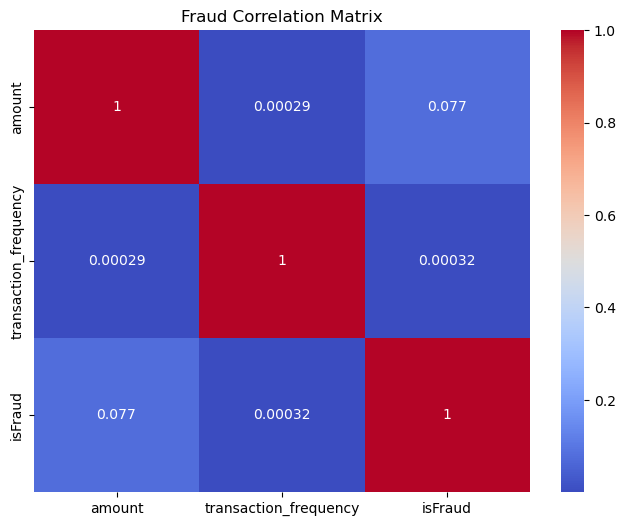

In [10]:
#Heatmap (Project Requirement)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Fraud Correlation Matrix'
)

plt.show()

In [11]:
#Create Velocity Feature
#Sort transactions
df = df.sort_values(
    ['nameOrig','step']
)

In [12]:
#Create velocity:
df['velocity'] = (
    df.groupby('nameOrig')
      ['step']
      .diff()
)

In [13]:
#Handle Missing Values
#First transaction of each customer has no previous transaction
df['velocity'].isnull().sum()

np.int64(6353307)

In [15]:
#Fill missing
df['velocity'] = (
    df['velocity']
    .fillna(999)
)
#No previous transaction available

In [16]:
#Verify Velocity
df[
    [
        'nameOrig',
        'step',
        'velocity'
    ]
].head(20)

,nameOrig,step,velocity
3196942,C1000000639,249,999.0
2798983,C1000001337,217,999.0
1013585,C1000001725,46,999.0
2980283,C1000002591,231,999.0
1920204,C1000003372,167,999.0
3374567,C1000003615,254,999.0
4548211,C1000004053,327,999.0
847860,C1000004530,41,999.0
2825292,C1000005353,226,999.0
2202461,C1000005555,185,999.0


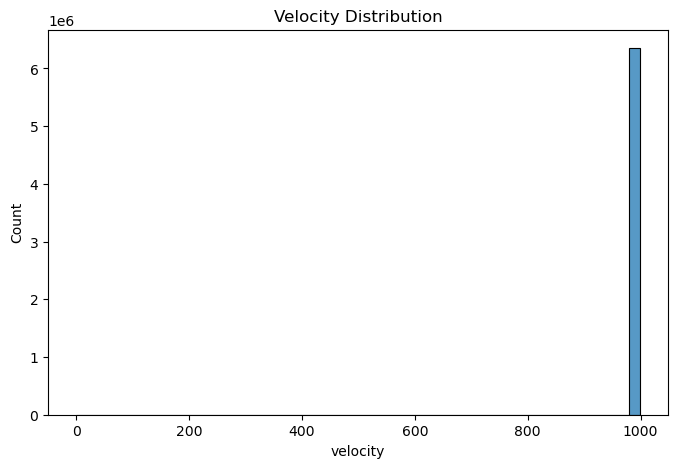

In [17]:
#Velocity Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['velocity'],
    bins=50
)

plt.title(
    'Velocity Distribution'
)

plt.show()

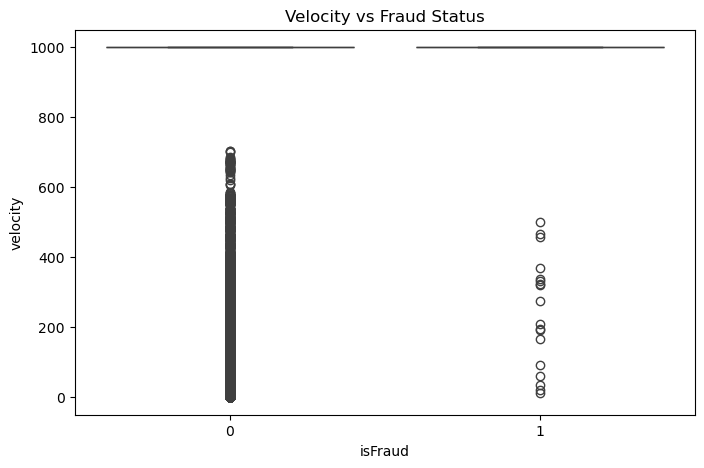

In [18]:
#Compare Velocity by Fraud Status
#Do fraudsters transact faster?
#Boxplot:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='isFraud',
    y='velocity',
    data=df
)

plt.title(
    'Velocity vs Fraud Status'
)

plt.show()

In [19]:
#Average Velocity
df.groupby(
    'isFraud'
)['velocity'].mean()

isFraud
0    997.770034
1    997.342141
Name: velocity, dtype: float64

In [20]:
#Fraud Rate by Frequency
df['frequency_group'] = pd.qcut(
    df['transaction_frequency'],
    q=4,
    duplicates='drop'
)

In [21]:
#Analyze
df.groupby(
    'frequency_group'
)['isFraud'].mean() * 100

C:\Users\PRANAY\AppData\Local\Temp\ipykernel_28552\1505818555.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


frequency_group
(0.999, 3.0]    0.129082
Name: isFraud, dtype: float64

In [22]:
#Create Final Feature Dataset
features_df = df[
    [
        'amount',
        'oldbalanceOrg',
        'newbalanceOrig',
        'oldbalanceDest',
        'newbalanceDest',
        'transaction_frequency',
        'velocity',
        'isFraud'
    ]
]

In [23]:
#Check:
features_df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud
3196942,244486.46,8946.00,0.00,526950.37,771436.84,1,999.0,0
2798983,3170.28,58089.00,54918.72,0.00,0.00,1,999.0,0
1013585,8424.74,783.00,0.00,0.00,0.00,1,999.0,0
2980283,261877.19,7596.00,269473.19,1126627.70,864750.51,1,999.0,0
1920204,20528.65,2302074.12,2322602.77,82696.17,62167.52,1,999.0,0


In [24]:
#Save Feature Dataset
features_df.to_csv(
    '../data/features_dataset.csv',
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\data'

In [25]:
import os
print(os.getcwd())

C:\Users\PRANAY


In [26]:
features_df.to_csv(
    'features_dataset.csv',
    index=False
)

In [27]:
import os
os.listdir()

['.anaconda',
 '.arduinoIDE',
 '.atom',
 '.conda',
 '.continuum',
 '.copilot',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.m2',
 '.matplotlib',
 '.packettracer',
 '.python_history',
 '.streamlit',
 '.vscode',
 '.vscode-shared',
 'aiot.ipynb',
 'anaconda3',
 'AppData',
 'Application Data',
 'battery-report.html',
 'Cisco Packet Tracer 9.0.0',
 'Contacts',
 'Cookies',
 'CrossDevice',
 'day1.ipynb',
 'Day1_Data_Inspection.ipynb',
 'day3_findings.md.ipynb',
 'day4_findings.md.ipynb',
 'day5_findings.md.ipynb',
 'Day6_EDA.ipynb',
 'Documents',
 'Downloads',
 'even.py',
 'Favorites',
 'features_dataset.csv',
 'hi.c',
 'IdeaProjects',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{06117720-04c7-11f0-9687-e0c03468deb1}.TM.blf',
 'NTUSER.DAT{06117720-04c7-11f0-9687-e0c03468deb1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{06117720-04c7-11f0-9687-e0c03468deb1}.